<a href="https://colab.research.google.com/github/Rony2019-2023/secure-cxr-detection-gbm-/blob/main/naive_bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from skimage.io import imread
from skimage.transform import resize
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, auc



In [ ]:
# Define the directory paths for positive and negative images
covid_dir = '/content/drive/MyDrive/Mydataset/TrainData/COVID-19'
non_covid_dir = '/content/drive/MyDrive/Mydataset/TrainData/Normal'

In [ ]:
# Load COVID-19 images and create label array
covid_images = []
covid_labels = []
for img_name in os.listdir(covid_dir):
    img_path = os.path.join(covid_dir, img_name)
    img = imread(img_path)
    img_resized = resize(img, (256, 256)) # Resize image to same dimensions
    covid_images.append(img_resized)
    covid_labels.append(1) # Label COVID-19 images as 1


In [ ]:
# Load non-COVID-19 images and create label array
non_covid_images = []
non_covid_labels = []
for img_name in os.listdir(non_covid_dir):
    img_path = os.path.join(non_covid_dir, img_name)
    img = imread(img_path)
    img_resized = resize(img, (256, 256)) # Resize image to same dimensions
    non_covid_images.append(img_resized)
    non_covid_labels.append(0) # Label non-COVID-19 images as 0

In [ ]:
# Combine COVID-19 and non-COVID-19 images and labels into arrays
images = np.array(covid_images + non_covid_images)
labels = np.array(covid_labels + non_covid_labels)

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)


In [ ]:
# Create Naive Bayes classifier
clf = GaussianNB()
clf.fit(X_train.reshape(len(X_train), -1), y_train)


GaussianNB()

In [ ]:
# Predict on test set and calculate accuracy
y_pred = clf.predict(X_test.reshape(len(X_test), -1))
accuracy = accuracy_score(y_test, y_pred)


In [ ]:
# Calculate metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

In [ ]:
# Print results
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)
print('Specificity:', specificity)
print('Accuracy:', accuracy)


Precision: 0.16129032258064516
Recall: 0.625
F1 Score: 0.2564102564102564
Specificity: 0.8594594594594595
Accuracy: 0.8497409326424871


<Axes: >

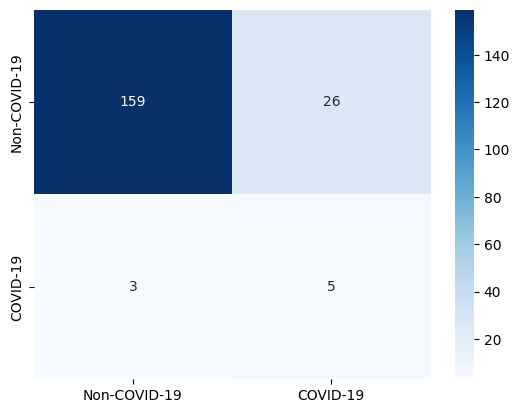

In [ ]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Define labels for the plot
labels = ['Non-COVID-19', 'COVID-19']

# Create heatmap plot
sns.heatmap(cm, cmap='Blues', annot=True, fmt='d', xticklabels=labels, yticklabels=labels)

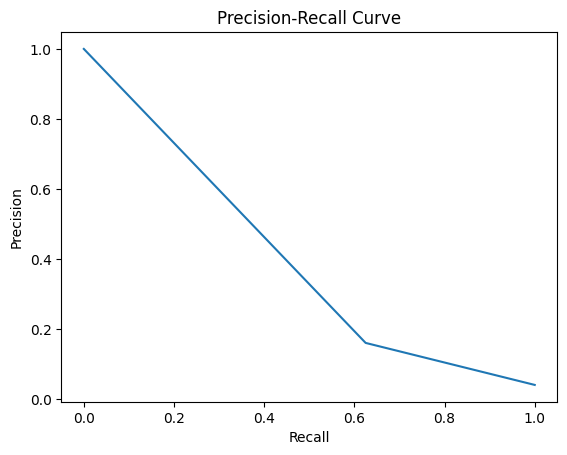

In [ ]:
# Calculate precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

# Plot precision-recall curve
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

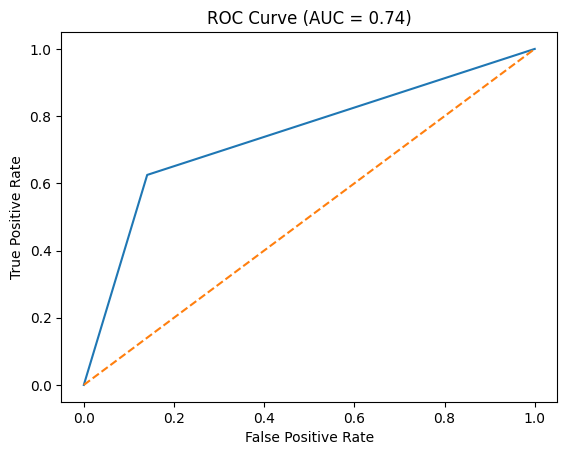

In [ ]:
# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--') # Plot baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (AUC = {:.2f})'.format(auc))
plt.show()

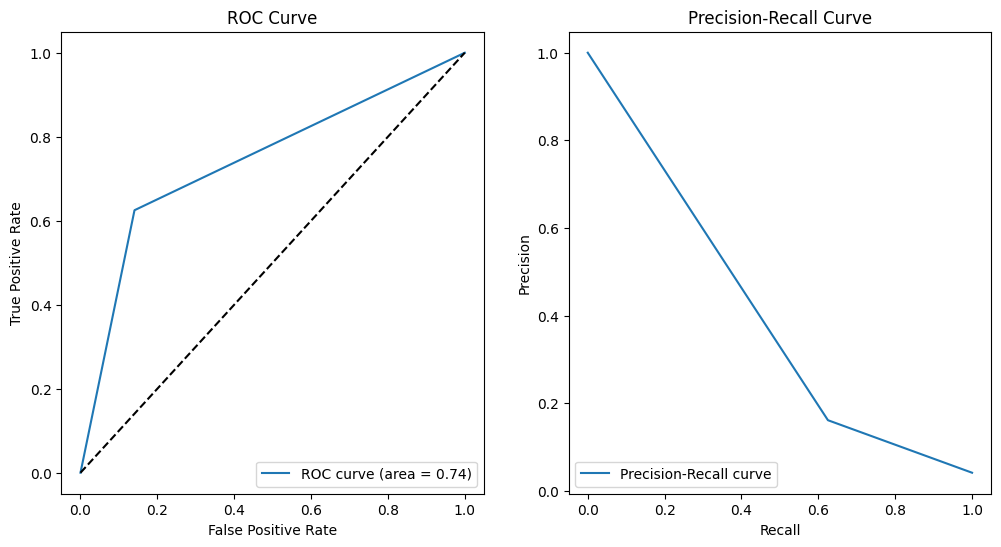

In [ ]:
# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

# Calculate precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

# Create subplots for P-R curve and ROC curve
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ROC curve
axs[0].plot(fpr, tpr, label='ROC curve (area = %0.2f)' % auc)
axs[0].plot([0, 1], [0, 1], 'k--')
axs[0].set_xlabel('False Positive Rate')
axs[0].set_ylabel('True Positive Rate')
axs[0].set_title('ROC Curve')
axs[0].legend(loc="lower right")

# Plot P-R curve
axs[1].plot(recall, precision, label='Precision-Recall curve')
axs[1].set_xlabel('Recall')
axs[1].set_ylabel('Precision')
axs[1].set_title('Precision-Recall Curve')
axs[1].legend(loc="lower left")

# Save and display the figure
fig.savefig('pr_roc_curves.png')
plt.show()